In [3]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

from scipy.io import arff
import pandas as pd

#os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

2026-04-07 13:28:39.668975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775561319.787822    7562 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775561319.827069    7562 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 13:28:40.165756: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:

data_arff, meta = arff.loadarff('hls4ml_HLF.arff')
df = pd.DataFrame(data_arff)

df['class'] = df['class'].str.decode('utf-8')

X = df.drop(columns=['class'])
y = df['class']

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Features: 16, Samples: 830000


In [4]:
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

(830000, 16) (830000,)
      zlogz  c1_b0_mmdt  c1_b1_mmdt  c1_b2_mmdt  c2_b1_mmdt  c2_b2_mmdt  \
0 -2.935125    0.383155    0.005126    0.000084    0.009070    0.000179   
1 -1.927335    0.270699    0.001585    0.000011    0.003232    0.000029   
2 -3.112147    0.458171    0.097914    0.028588    0.124278    0.038487   
3 -2.666515    0.437068    0.049122    0.007978    0.047477    0.004802   
4 -2.484843    0.428981    0.041786    0.006110    0.023066    0.001123   

   d2_b1_mmdt  d2_b2_mmdt  d2_a1_b1_mmdt  d2_a1_b2_mmdt  m2_b1_mmdt  \
0    1.769445    2.123898       1.769445       0.308185    0.135687   
1    2.038834    2.563099       2.038834       0.211886    0.063729   
2    1.269254    1.346238       1.269254       0.246488    0.115636   
3    0.966505    0.601864       0.966505       0.160756    0.082196   
4    0.552002    0.183821       0.552002       0.084338    0.048006   

   m2_b2_mmdt  n2_b1_mmdt  n2_b2_mmdt   mass_mmdt  multiplicity  
0    0.083278    0.412136    0.29

In [4]:
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, 5)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y[:5])

[[1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]


In [5]:
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

In [1]:
np.save('X_train_val.npy', X_train_val)
np.save('X_test.npy', X_test)
np.save('y_train_val.npy', y_train_val)
np.save('y_test.npy', y_test)
np.save('classes.npy', le.classes_)

NameError: name 'np' is not defined

In [4]:
X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1

In [13]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

In [ ]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Create the output directory manually
os.makedirs('model_baseline', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=1000, verbose=1),
    ModelCheckpoint(filepath='model_baseline/best_model.weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0000001, verbose=1),
]

adam = Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
model.fit(
    X_train_val, 
    y_train_val, 
    epochs=10, 
    batch_size=1024, 
    validation_split=0.25, 
    shuffle=True, 
    callbacks=callbacks
)
model.save('model_baseline/KERAS_check_best_model.keras')

Epoch 1/10
487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3286 - loss: 1.5115
Epoch 1: val_loss improved from None to 1.14976, saving model to model_baseline/best_model.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4615 - loss: 1.3469 - val_accuracy: 0.5867 - val_loss: 1.1498 - learning_rate: 1.0000e-04
Epoch 2/10
485/487 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6110 - loss: 1.1119
Epoch 2: val_loss improved from 1.14976 to 1.03138, saving model to model_baseline/best_model.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6321 - loss: 1.0794 - val_accuracy: 0.6599 - val_loss: 1.0314 - learning_rate: 1.0000e-04
Epoch 3/10
481/487 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6653 - loss: 1.0151
Epoch 3: val_loss improved from 1.03138 to 0.97024, saving model to model_baseline/best_model.weights.h5
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6736 - loss: 0.9973 - val_accuracy: 0.6898 - val_loss: 0.9702 - learning_rate: 1.0000

% of zeros = 0.0


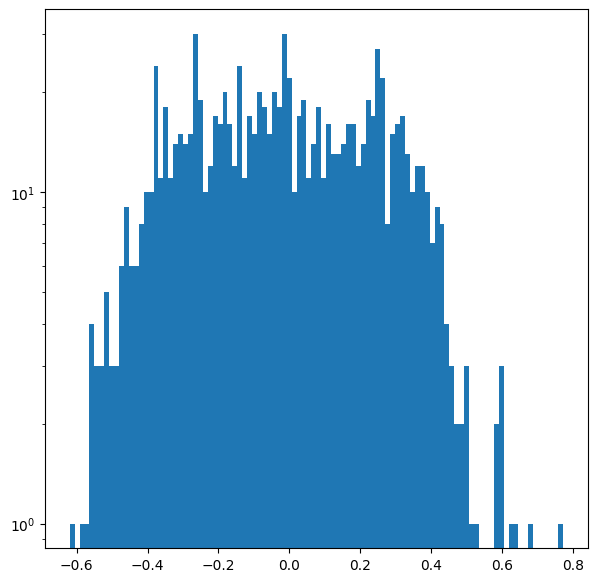

In [15]:
w = model.layers[0].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))

In [16]:
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

# 3. Evaluate

score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.8193845152854919
Test accuracy: 0.7345843315124512


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Accuracy: 0.7345843373493975


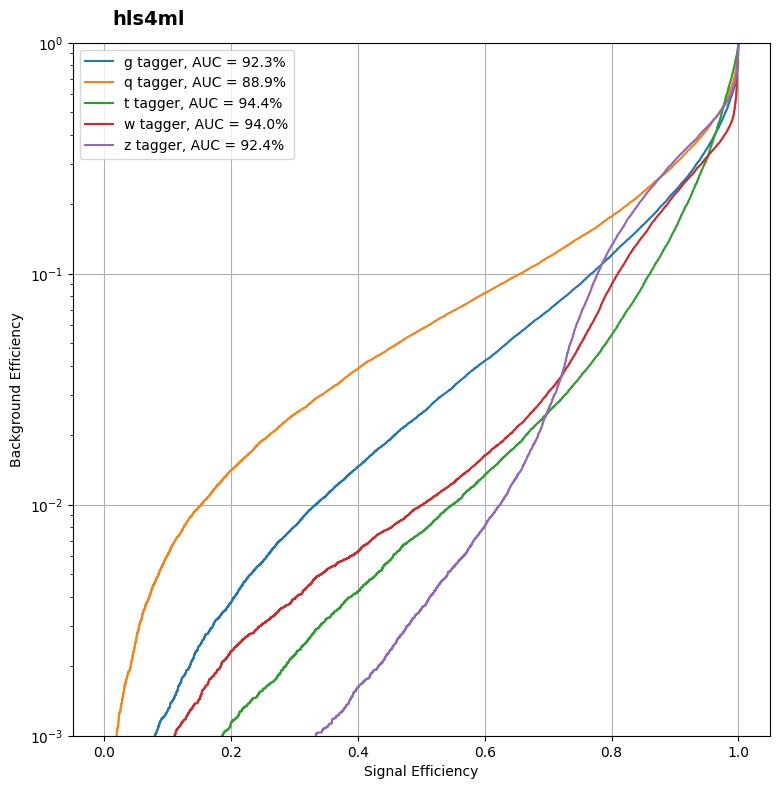

In [17]:
import plotting
from sklearn.metrics import accuracy_score

y_keras = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, classes)


In [28]:
import hls4ml


config = hls4ml.utils.config_from_keras_model(model, granularity='name', backend='Vitis')

# Ensure you set Trace=True in your config for the layers you want to see
# Or just enable it for all:
for layer in config['LayerName'].keys():
    config['LayerName'][layer]['Trace'] = True
    
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_baseline/hls4ml_prj', part='xcu250-figd2104-2L-e'
)
hls_model.compile()


# Get internal layer outputs
# hls_trace is a dict: {'layer_name': array_of_fixed_point_values}
keras_trace, hls_trace = hls4ml.model.profiling.get_model_trace(model, hls_model, X_test[:100])


AttributeError: module 'hls4ml.model.profiling' has no attribute 'get_model_trace'

In [ ]:
from tensorflow.keras.models import load_model
model_baseline = load_model('model_baseline/KERAS_check_best_model.keras')